<a href="https://colab.research.google.com/github/vedika01105/4_VEDIKA_SISODIYA_D2/blob/main/Logistic_Regression_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATASET

In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=42, hypercube=False, class_sep=10)

In [3]:
X.shape

(100, 2)

In [4]:
y.shape

(100,)

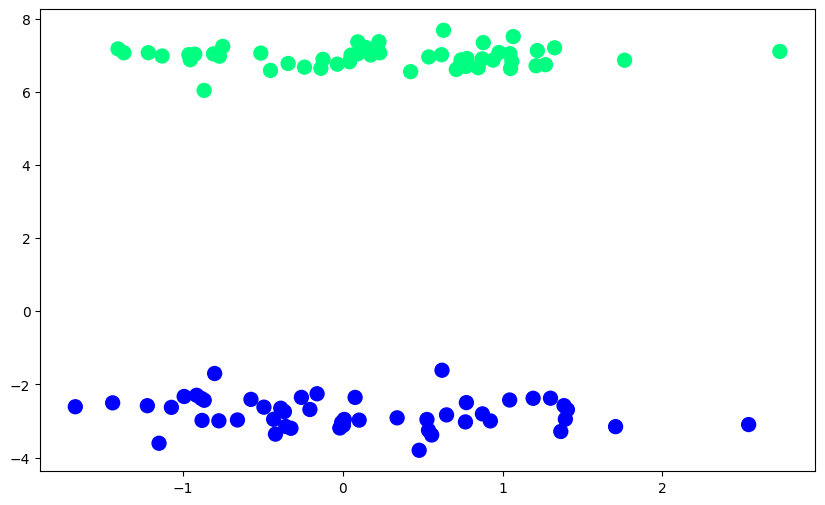

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter',s=100)

# PERCEPTRON TRICK WITH STEP FUNCTION

In [6]:
def perceptron1(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j],weights))
    weights = weights + lr*(y[j]-y_hat)*X[j]

  return weights[0], weights[1:]

In [7]:
def step(z):
  return 1 if z>=0 else 0

In [8]:
intercept1_, coef1_ = perceptron1(X,y)
print(intercept1_, coef1_)

0.9 [0.74608373 1.30991644]


In [9]:
m = -(coef1_[0]/coef1_[1])
b = -(intercept1_/coef1_[1])

In [10]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m * x_input1 + b

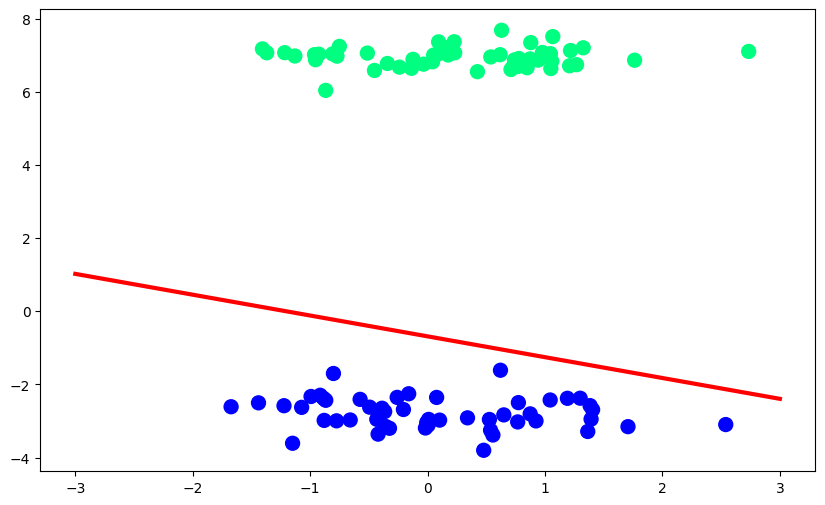

In [11]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
# plt.ylim(-3,2)

# USING SIGMOID FUNCTION

In [12]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [13]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [14]:
intercept2_, coef2_ = perceptron(X,y)
print(intercept2_, coef2_)

0.4143738555288162 [0.66433843 2.49714716]


In [15]:
m = -(coef2_[0]/coef2_[1])
b = -(intercept2_/coef2_[1])

In [16]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m * x_input2 + b

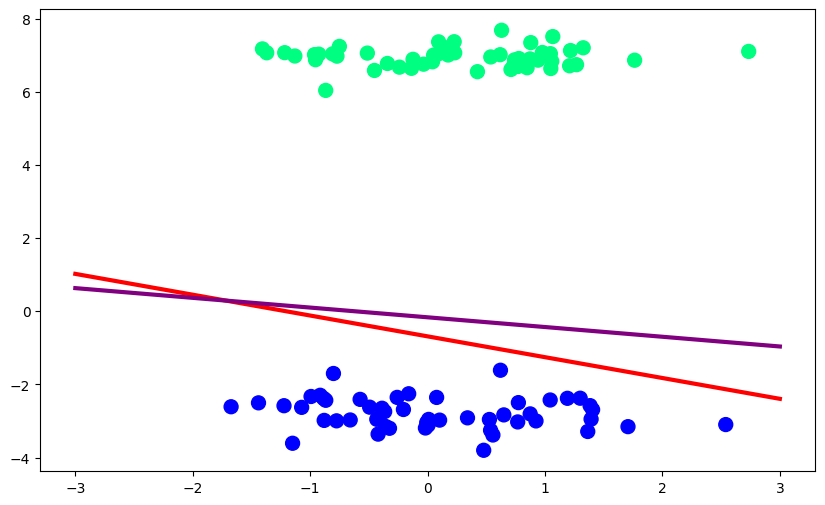

In [17]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.plot(x_input2,y_input2,color='purple',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
# plt.ylim(-3,2)

## USING GRADIENT DESCENT

In [53]:
def gd(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(10000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])

  return weights[1:],weights[0]


In [54]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [55]:
coef3_,intercept3_ = gd(X,y)
print(coef3_, intercept3_)

[0.51810729 3.30438106] 0.026907744109304254


In [56]:
m = -(coef3_[0]/coef3_[1])
b = -(intercept3_/coef3_[1])

In [57]:
x_input3 = np.linspace(-3,3,100)
y_input3 = m*x_input3 + b

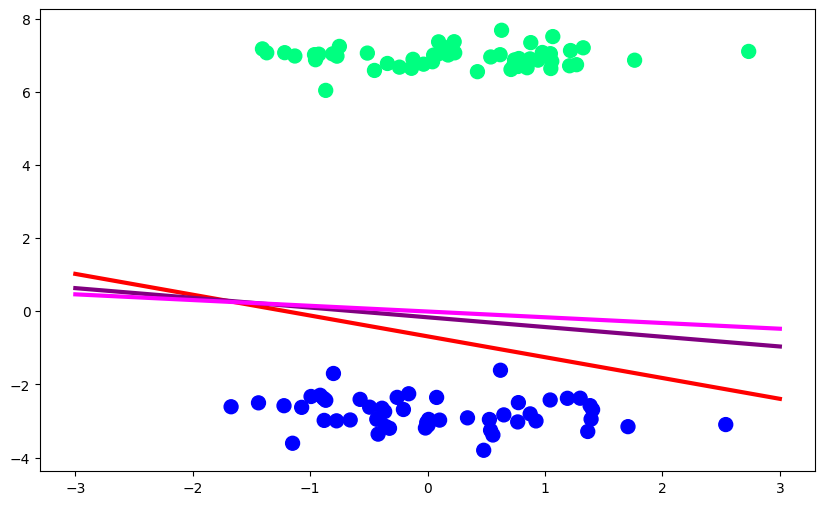

In [58]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.plot(x_input2,y_input2,color='purple',linewidth=3)
plt.plot(x_input3,y_input3,color='magenta',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
# plt.ylim(-3,2)

## USING LOGISTIC REGRESSION CLASS

In [59]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [60]:
print(lor.intercept_, lor.coef_)

[-2.6353538] [[0.02930564 1.23949751]]


In [61]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_[0] / lor.coef_[0][1])

In [62]:
x_input4 = np.linspace(-3,3,100)
y_input4 = m*x_input4 + b

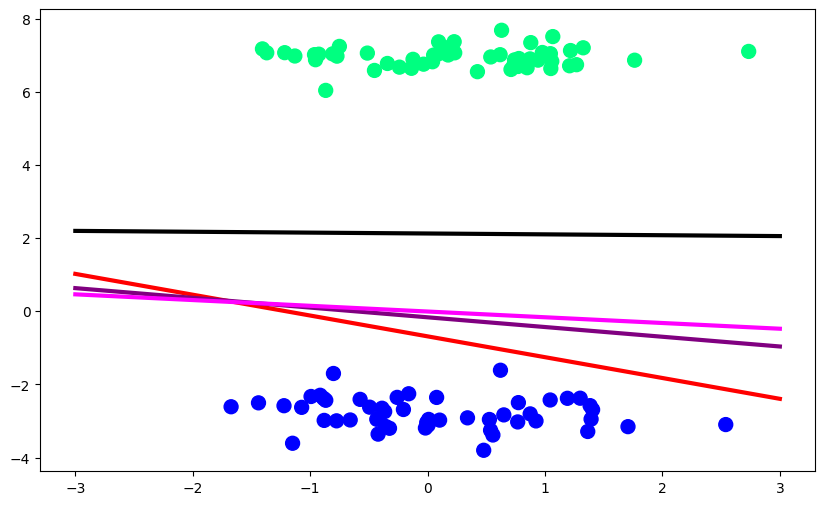

In [63]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.plot(x_input2,y_input2,color='purple',linewidth=3)
plt.plot(x_input3,y_input3,color='magenta',linewidth=3)
plt.plot(x_input4,y_input4,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
# plt.ylim(-3,2)